# Neural Networks on real data

so far i only tested the net on tiny toy data. time to throw it at real datasets, and also show the same idea does regression not just classification. three tasks: binary classification (breast cancer, with my own net), multiclass (digits), and regression (diabetes).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_digits, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, r2_score

## part 1: breast cancer (our own net)

the same from-scratch net from notebook 02, now on real 30-feature data. standardize first, neural nets really need scaled inputs.

In [2]:
# the from-scratch net again (1 hidden layer, tanh + sigmoid)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(X, p):
    a1 = np.tanh(X @ p['W1'] + p['b1'])
    a2 = sigmoid(a1 @ p['W2'] + p['b2'])
    return a1, a2

def train(X, y, nh=16, lr=0.1, epochs=3000, seed=0):
    r = np.random.default_rng(seed)
    m = len(y)
    p = {'W1': r.normal(0, 1, (X.shape[1], nh)) * 0.3, 'b1': np.zeros((1, nh)),
         'W2': r.normal(0, 1, (nh, 1)) * 0.3, 'b2': np.zeros((1, 1))}
    losses = []
    for e in range(epochs):
        a1, a2 = forward(X, p)
        dz2 = a2 - y
        dW2 = a1.T @ dz2 / m; db2 = np.mean(dz2, 0, keepdims=True)
        dz1 = (dz2 @ p['W2'].T) * (1 - a1 ** 2)
        dW1 = X.T @ dz1 / m; db1 = np.mean(dz1, 0, keepdims=True)
        p['W1'] -= lr * dW1; p['b1'] -= lr * db1
        p['W2'] -= lr * dW2; p['b2'] -= lr * db2
        if e % 100 == 0:
            losses.append(-np.mean(y * np.log(a2 + 1e-9) + (1 - y) * np.log(1 - a2 + 1e-9)))
    return p, losses

def predict(X, p):
    return (forward(X, p)[1] >= 0.5).astype(int)

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target.reshape(-1, 1)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
Xtr = sc.fit_transform(Xtr)
Xte = sc.transform(Xte)

p, losses = train(Xtr, ytr.astype(float))
print("our net test accuracy:", round(accuracy_score(yte, predict(Xte, p)), 3))

our net test accuracy: 0.965


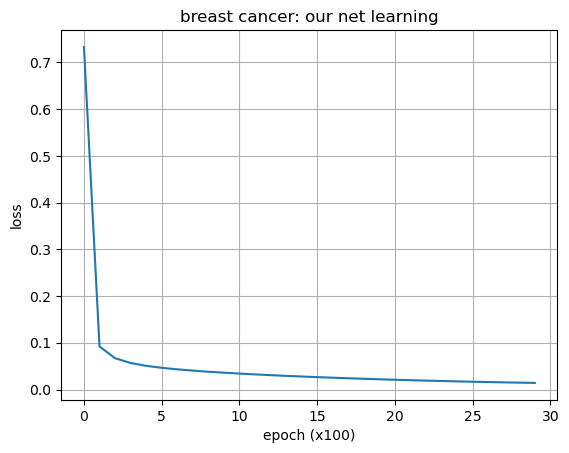

In [4]:
plt.plot(losses)
plt.title("breast cancer: our net learning")
plt.xlabel("epoch (x100)"); plt.ylabel("loss"); plt.grid(True); plt.show()

In [5]:
# sanity check against sklearn's MLP
skl = MLPClassifier(hidden_layer_sizes=(16,), max_iter=1000, random_state=1).fit(Xtr, ytr.ravel())
print("sklearn MLP test accuracy:", round(skl.score(Xte, yte.ravel()), 3))

sklearn MLP test accuracy: 0.947


## part 2: handwritten digits (multiclass)

digits are 8x8 images, 10 classes (0 to 9). multiclass needs a softmax output, so i use sklearn's MLP here, same idea with softmax + cross entropy under the hood.

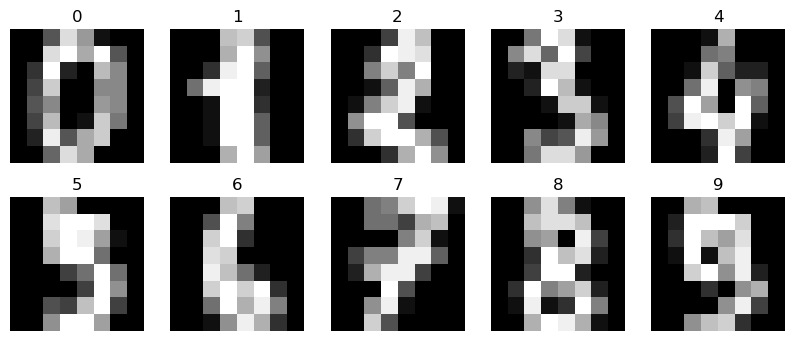

In [7]:
digits = load_digits()

# what the data looks like
fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i, a in enumerate(ax.flat):
    a.imshow(digits.images[i], cmap='gray')
    a.set_title(digits.target[i]); a.axis('off')
plt.show()

In [8]:
Xtr_raw, Xte_raw, ytr, yte = train_test_split(digits.data, digits.target,
                                              test_size=0.2, random_state=42)
sc = StandardScaler()
Xtr = sc.fit_transform(Xtr_raw); Xte = sc.transform(Xte_raw)

clf = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', max_iter=1000, random_state=1)
clf.fit(Xtr, ytr)
print("digits test accuracy:", round(clf.score(Xte, yte), 3))

digits test accuracy: 0.969


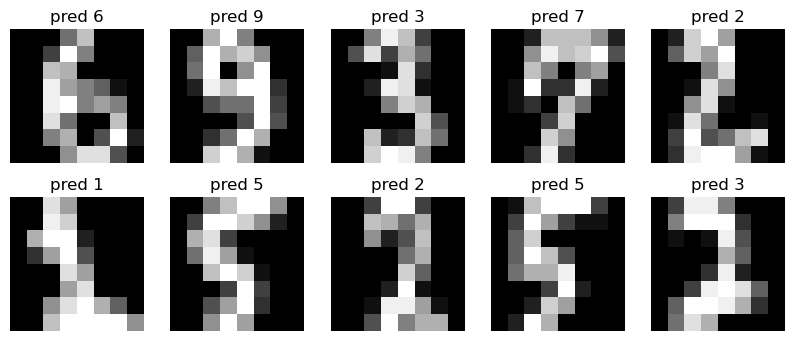

In [9]:
# see some actual predictions
preds = clf.predict(Xte)

fig, ax = plt.subplots(2, 5, figsize=(10, 4))
for i, a in enumerate(ax.flat):
    a.imshow(Xte_raw[i].reshape(8, 8), cmap='gray')
    a.set_title(f"pred {preds[i]}"); a.axis('off')
plt.show()

## part 3: regression (diabetes)

same network idea but now predicting a continuous number instead of a class. the output is just linear and the loss is MSE. diabetes is a hard dataset so its not super accurate, but it shows the net does regression too.

In [11]:
db = load_diabetes()
Xtr, Xte, ytr, yte = train_test_split(db.data, db.target, test_size=0.2, random_state=42)
sc = StandardScaler(); Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)

reg = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', max_iter=2000, random_state=1)
reg.fit(Xtr, ytr)
pred = reg.predict(Xte)
r2 = r2_score(yte, pred)
print("diabetes R2:", round(r2, 3))

diabetes R2: 0.411


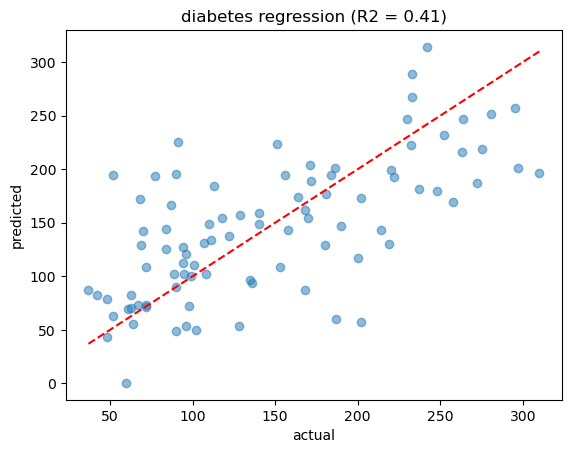

In [12]:
plt.scatter(yte, pred, alpha=0.5)
plt.plot([yte.min(), yte.max()], [yte.min(), yte.max()], 'r--')   # perfect would sit on this line
plt.xlabel("actual"); plt.ylabel("predicted")
plt.title(f"diabetes regression (R2 = {r2:.2f})")
plt.show()

so the exact same neural network idea handles all of it, binary classification, multiclass, and regression. you just swap the output and the loss, sigmoid for binary, softmax for multiclass, linear for regression. thats the whole module, from one perceptron that couldnt do XOR, to a net that does basically any task.